In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from plotting_functions import custom_plots
plt.rcParams.update(custom_plots())

In [3]:
data = pd.read_csv("predictions_ancestral_median.csv")
data

,protein_id,ABRIMXGLNHCLIP-UHFFFAOYSA-N,ACBMYYVZWKYLIP-UHFFFAOYSA-N,ACWQBUSCFPJUPN-UHFFFAOYSA-N,ACZGCWSMSTYWDQ-UHFFFAOYSA-N,AEMFNILZOJDQLW-UHFFFAOYSA-N,AIVVNNYXOSPRCW-UHFFFAOYSA-N,AKGGYBADQZYZPD-UHFFFAOYSA-N,ALHUZKCOMYUFRB-UHFFFAOYSA-N,ALVPFGSHPUPROW-UHFFFAOYSA-N,...,ZSKAJFSSXURRGL-UHFFFAOYSA-N,ZTQSAGDEMFDKMZ-UHFFFAOYSA-N,ZVEZMVFBMOOHAT-UHFFFAOYSA-N,ZWEHNKRNPOVVGH-UHFFFAOYSA-N,ZWKNLRXFUTWSOY-UHFFFAOYSA-N,ZWRUINPWMLAQRD-UHFFFAOYSA-N,ZXEKIIBDNHEJCQ-UHFFFAOYSA-N,ZYEMGPIYFIJGTP-UHFFFAOYSA-N,ZYGHJZDHTFUPRJ-UHFFFAOYSA-N,ZYIJXTQXQNXPSH-UHFFFAOYSA-N
0,node_1,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,node_10,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,node_100,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,node_101,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
4,node_102,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,node_95,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
578,node_96,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
579,node_97,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
580,node_98,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


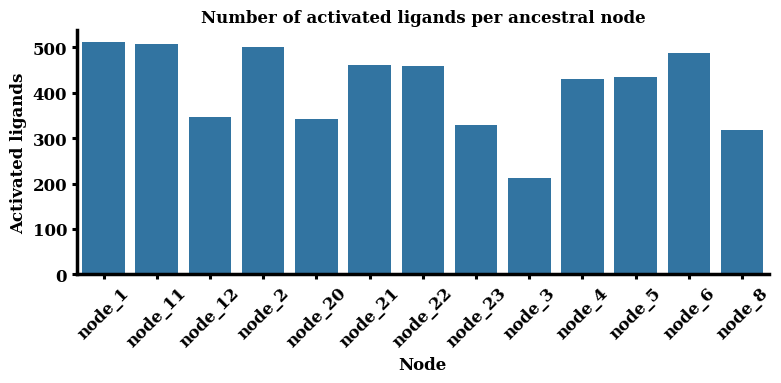

In [4]:
#Barplot: number of activated ligands per node
target_nodes = [
    "node_1", "node_2", "node_3", "node_4", "node_5", "node_6",
    "node_8", "node_11", "node_12", "node_20", "node_21", "node_22", "node_23"
]

subset = data[data["protein_id"].isin(target_nodes)].copy()
subset["node_num"] = subset["protein_id"].str.replace("node_", "", regex=False).astype(int)
subset = subset.sort_values("node_num").drop(columns="node_num")
subset = subset.set_index("protein_id")

# count activated ligands per node
activation_counts = subset.sum(axis=1).sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(
    x=activation_counts.index,
    y=activation_counts.values
)
plt.title("Number of activated ligands per ancestral node")
plt.xlabel("Node")
plt.ylabel("Activated ligands")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
activation_counts

protein_id
node_1     512.0
node_11    507.0
node_12    346.0
node_2     500.0
node_20    342.0
node_21    462.0
node_22    459.0
node_23    330.0
node_3     212.0
node_4     431.0
node_5     435.0
node_6     488.0
node_8     319.0
dtype: float64

In [6]:
#Table of unique ligands per node
unique_ligands = {}

for node in subset.index:
    node_active = set(subset.columns[subset.loc[node] == 1])
    other_active = set(subset.columns[(subset.drop(index=node) == 1).any(axis=0)])
    unique_ligands[node] = sorted(node_active - other_active)

# summary table
unique_summary = pd.DataFrame({
    "node": list(unique_ligands.keys()),
    "n_unique_ligands": [len(v) for v in unique_ligands.values()]
})

display(unique_summary)

for node, ligs in unique_ligands.items():
    print(f"\n{node} ({len(ligs)} unique ligands):")
    print(ligs[:20])
    
### TODO: UNIQUE LIGANDS --> THEIR ODOR TAGS

,node,n_unique_ligands
0,node_1,2
1,node_2,4
2,node_3,0
3,node_4,0
4,node_5,0
5,node_6,3
6,node_8,3
7,node_11,7
8,node_12,0
9,node_20,0



node_1 (2 unique ligands):
['SKQYTJLYRIFFCO-UHFFFAOYSA-N', 'XLSMFKSTNGKWQX-UHFFFAOYSA-N']

node_2 (4 unique ligands):
['FJPGAMCQJNLTJC-UHFFFAOYSA-N', 'NGAZZOYFWWSOGK-UHFFFAOYSA-N', 'OVNCGQSYSSYBPO-UHFFFAOYSA-N', 'WRFXXJKURVTLSY-UHFFFAOYSA-N']

node_3 (0 unique ligands):
[]

node_4 (0 unique ligands):
[]

node_5 (0 unique ligands):
[]

node_6 (3 unique ligands):
['IFNDEOYXGHGERA-UHFFFAOYSA-N', 'LNIMMWYNSBZESE-UHFFFAOYSA-N', 'PETRWTHZSKVLRE-UHFFFAOYSA-N']

node_8 (3 unique ligands):
['IYTXKIXETAELAV-UHFFFAOYSA-N', 'SXOZDDAFVJANJP-UHFFFAOYSA-N', 'WSTQLNQRVZNEDV-UHFFFAOYSA-N']

node_11 (7 unique ligands):
['BKWHDPNQDGBHET-UHFFFAOYSA-N', 'HXYVTAGFYLMHSO-UHFFFAOYSA-N', 'LHGVFZTZFXWLCP-UHFFFAOYSA-N', 'MVLVMROFTAUDAG-UHFFFAOYSA-N', 'NBBJYMSMWIIQGU-UHFFFAOYSA-N', 'OQWNKUAZQSLNSR-UHFFFAOYSA-N', 'ZTQSAGDEMFDKMZ-UHFFFAOYSA-N']

node_12 (0 unique ligands):
[]

node_20 (0 unique ligands):
[]

node_21 (0 unique ligands):
[]

node_22 (0 unique ligands):
[]

node_23 (0 unique ligands):
[]


In [7]:
#Shared ligands across all selected nodes
shared_by_all = subset.columns[(subset == 1).all(axis=0)].tolist()

print(f"Shared ligands across all selected nodes: {len(shared_by_all)}")
print(shared_by_all[:50])

Shared ligands across all selected nodes: 119
['AEMFNILZOJDQLW-UHFFFAOYSA-N', 'BJIOGJUNALELMI-UHFFFAOYSA-N', 'BKJFDZSBZWHRNH-UHFFFAOYSA-N', 'BSAIUMLZVGUGKX-UHFFFAOYSA-N', 'CCPPLLJZDQAOHD-UHFFFAOYSA-N', 'CRDAMVZIKSXKFV-UHFFFAOYSA-N', 'CRIGTVCBMUKRSL-UHFFFAOYSA-N', 'CXENHBSYCFFKJS-UHFFFAOYSA-N', 'DHMQDGOQFOQNFH-UHFFFAOYSA-N', 'DNRJTBAOUJJKDY-UHFFFAOYSA-N', 'DVVATNQISMINCX-UHFFFAOYSA-N', 'FBUKVWPVBMHYJY-UHFFFAOYSA-N', 'FCCDDURTIIUXBY-UHFFFAOYSA-N', 'FEWLNYSYJNLUOO-UHFFFAOYSA-N', 'FQMZVFJYMPNUCT-UHFFFAOYSA-N', 'FQTLCLSUCSAZDY-UHFFFAOYSA-N', 'FYGUSUBEMUKACF-UHFFFAOYSA-N', 'FYTRVXSHONWYNE-UHFFFAOYSA-N', 'GHVNFZFCNZKVNT-UHFFFAOYSA-N', 'GJJSUPSPZIZYPM-UHFFFAOYSA-N', 'GLZPCOQZEFWAFX-UHFFFAOYSA-N', 'GRLJIIJNZJVMGP-UHFFFAOYSA-N', 'GTGTXZRPJHDASG-UHFFFAOYSA-N', 'GVONPEQEUQYVNH-UHFFFAOYSA-N', 'GXANMBISFKBPEX-UHFFFAOYSA-N', 'HETFMJQWNWIBPN-UHFFFAOYSA-N', 'HFVMLYAGWXSTQI-UHFFFAOYSA-N', 'HGEVGSTXQGZPCL-UHFFFAOYSA-N', 'HIGQPQRQIQDZMP-UHFFFAOYSA-N', 'HNDHDMOSWUAEAW-UHFFFAOYSA-N', 'HQKQRXZEXPXXIG-UHFFFAO

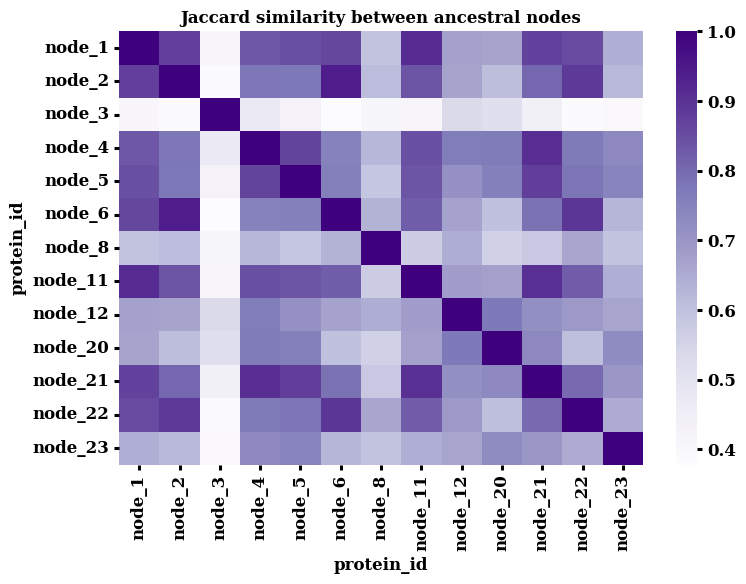

In [8]:
#Pairwise overlap matrix (Jaccard similarity: intersection over union)
import numpy as np

nodes = subset.index
jaccard = pd.DataFrame(index=nodes, columns=nodes, dtype=float)
shared_counts = pd.DataFrame(index=nodes, columns=nodes, dtype=int)

for n1 in nodes:
    s1 = set(subset.columns[subset.loc[n1] == 1])
    for n2 in nodes:
        s2 = set(subset.columns[subset.loc[n2] == 1])
        inter = len(s1 & s2)
        union = len(s1 | s2)
        jaccard.loc[n1, n2] = inter / union if union > 0 else 0
        shared_counts.loc[n1, n2] = inter

plt.figure(figsize=(8, 6))
sns.heatmap(jaccard, annot=False, fmt=".2f", cmap="Purples")
plt.title("Jaccard similarity between ancestral nodes")
plt.tight_layout()
plt.show()

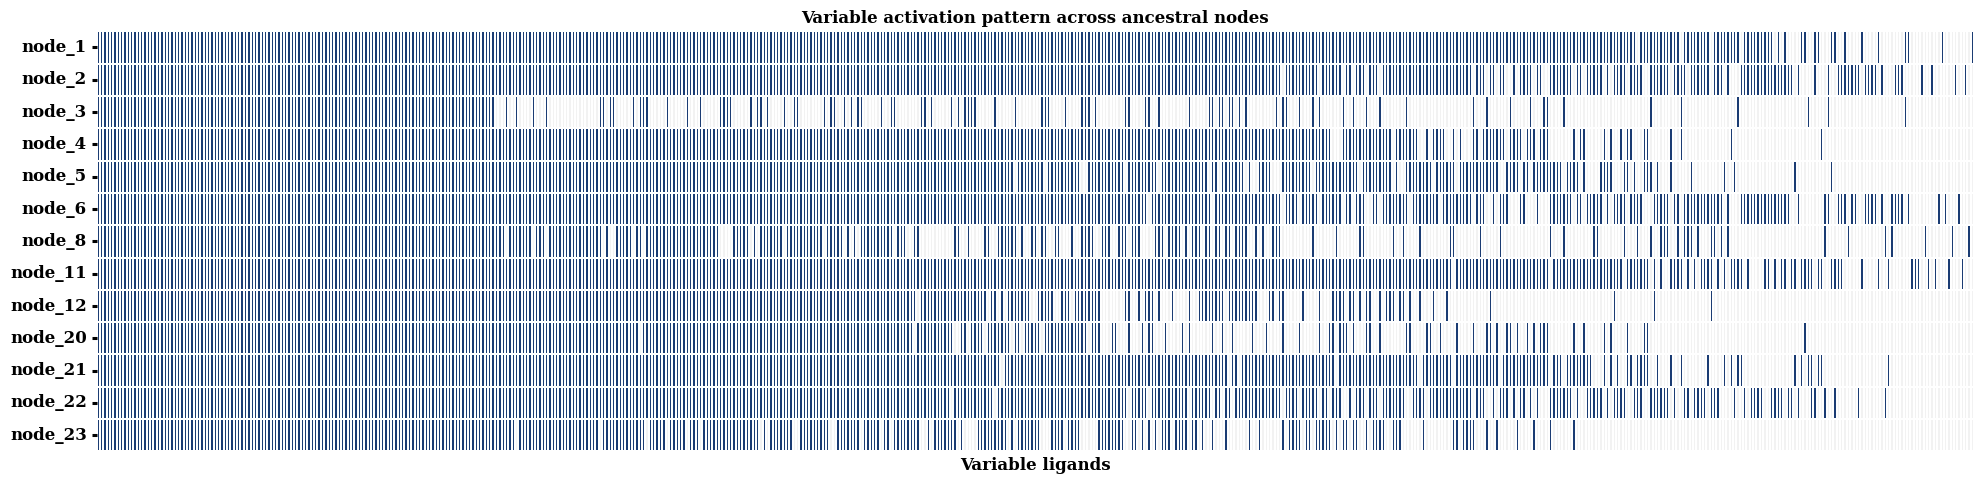

In [9]:
# keep only ligands activated by at least one node
informative = subset.loc[:, subset.sum(axis=0) > 0]

# optional: keep only variable ligands (not all 0, not all 1 across nodes)
#informative = informative.loc[:, informative.sum(axis=0).between(1, len(informative)-1)]

# sort ligands by how many nodes activate them
informative = informative.loc[:, informative.sum(axis=0).sort_values(ascending=False).index]

plt.figure(figsize=(20, 5))
sns.heatmap(
    informative,
    cmap=sns.color_palette(["#f2f2f2", "#1b3c73"]),
    cbar=False,
    xticklabels=False,
    yticklabels=True,
    linewidths=0.2,
    linecolor="white"
)
plt.title("Variable activation pattern across ancestral nodes")
plt.xlabel("Variable ligands")
plt.ylabel("")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1600x1000 with 0 Axes>

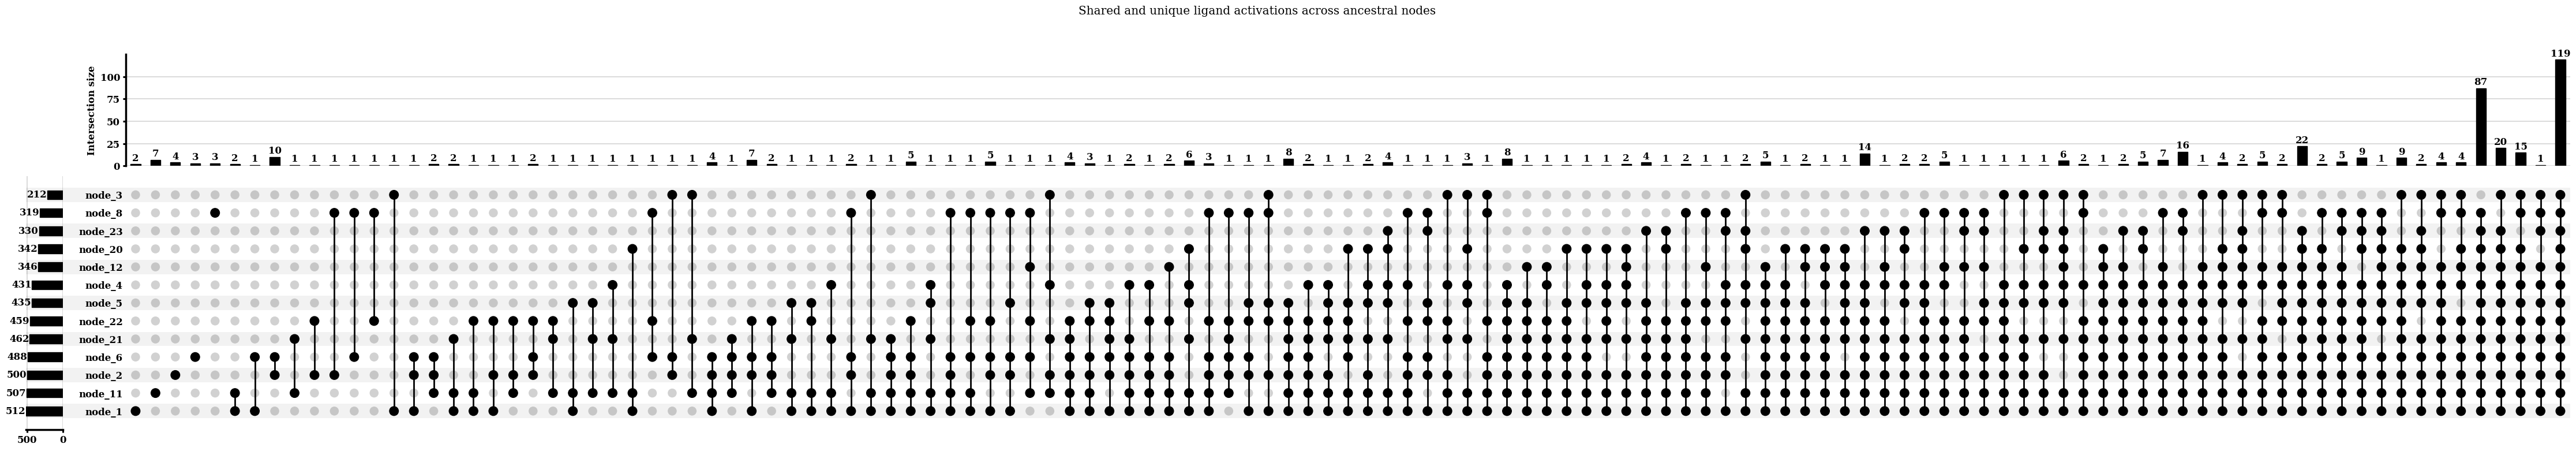

In [ ]:
#the upset plot is really interesting. if i have understand correct, on the y-axis we have the intersection size, so i think we dont need to plot those that are one.
#UpSet-style analysis
from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt

node_sets = {
    node: set(subset.columns[subset.loc[node] == 1])
    for node in subset.index
}

upset_data = from_contents(node_sets)

plt.figure(figsize=(16, 10))
UpSet(upset_data, subset_size='count', show_counts=True).plot()
plt.suptitle("Shared and unique ligand activations across ancestral nodes")
plt.show()

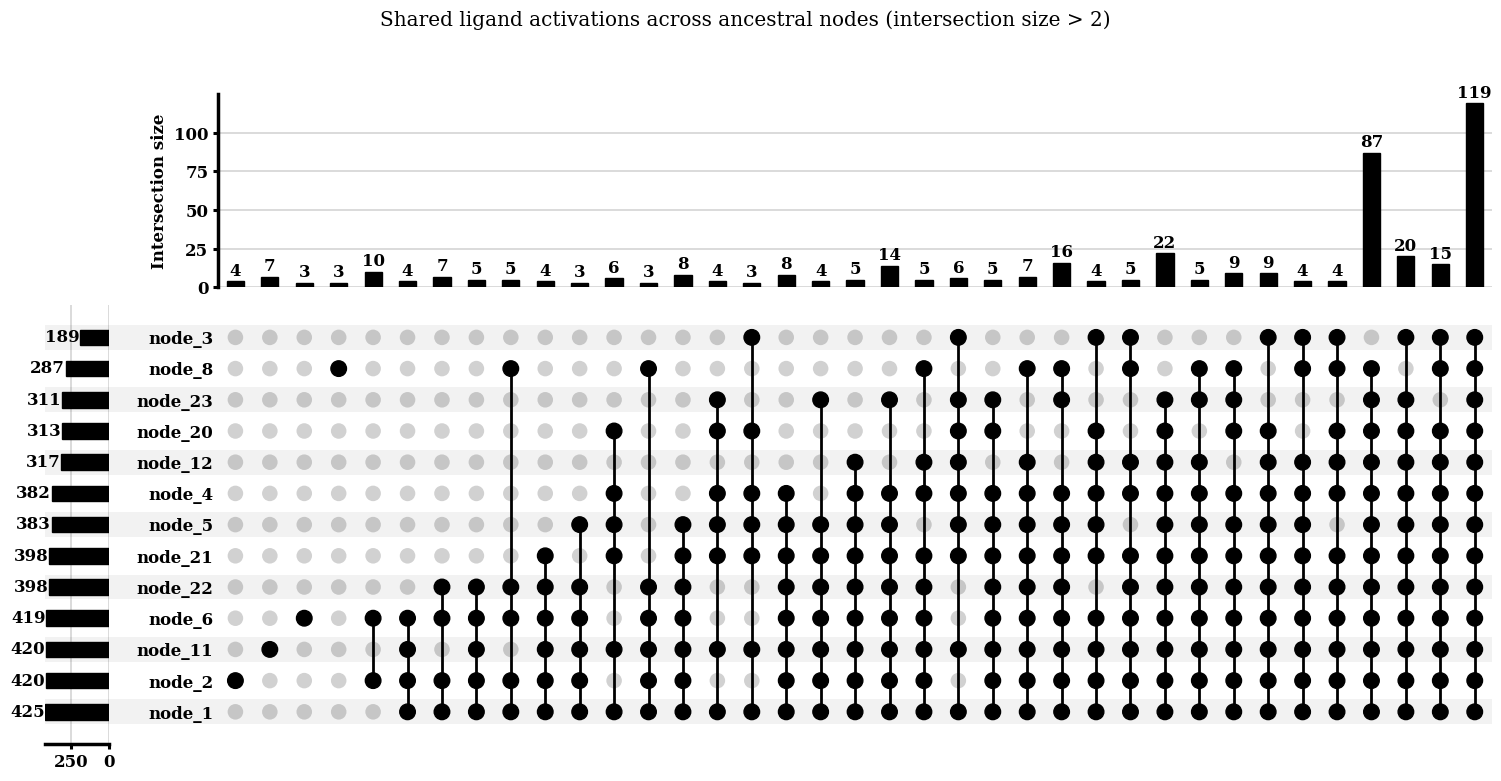

In [46]:
from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt
import pandas as pd

# build sets
node_sets = {
    node: set(subset.columns[subset.loc[node] == 1])
    for node in subset.index
}

# rows = ligands, multiindex = membership pattern
upset_data = from_contents(node_sets)

# count ligands per intersection pattern
intersection_counts = upset_data.groupby(level=list(range(upset_data.index.nlevels))).size()

# keep only intersection patterns with more than 1 ligand
valid_intersections = intersection_counts[intersection_counts > 2].index

# subset original data
upset_data_filtered = upset_data.loc[valid_intersections]

# plot
up = UpSet(
    upset_data_filtered,
    subset_size='count',
    show_counts=True
)

up.plot()
plt.suptitle("Shared ligand activations across ancestral nodes (intersection size > 2)")
plt.show()

In [12]:
ligand_node_counts = subset.sum(axis=0)
single_node_ligands = ligand_node_counts[ligand_node_counts == 1].index.tolist()

print(f"Ligands activated by exactly one node: {len(single_node_ligands)}")
print(single_node_ligands[:50])

Ligands activated by exactly one node: 19
['BKWHDPNQDGBHET-UHFFFAOYSA-N', 'FJPGAMCQJNLTJC-UHFFFAOYSA-N', 'HXYVTAGFYLMHSO-UHFFFAOYSA-N', 'IFNDEOYXGHGERA-UHFFFAOYSA-N', 'IYTXKIXETAELAV-UHFFFAOYSA-N', 'LHGVFZTZFXWLCP-UHFFFAOYSA-N', 'LNIMMWYNSBZESE-UHFFFAOYSA-N', 'MVLVMROFTAUDAG-UHFFFAOYSA-N', 'NBBJYMSMWIIQGU-UHFFFAOYSA-N', 'NGAZZOYFWWSOGK-UHFFFAOYSA-N', 'OQWNKUAZQSLNSR-UHFFFAOYSA-N', 'OVNCGQSYSSYBPO-UHFFFAOYSA-N', 'PETRWTHZSKVLRE-UHFFFAOYSA-N', 'SKQYTJLYRIFFCO-UHFFFAOYSA-N', 'SXOZDDAFVJANJP-UHFFFAOYSA-N', 'WRFXXJKURVTLSY-UHFFFAOYSA-N', 'WSTQLNQRVZNEDV-UHFFFAOYSA-N', 'XLSMFKSTNGKWQX-UHFFFAOYSA-N', 'ZTQSAGDEMFDKMZ-UHFFFAOYSA-N']


In [13]:
single_ligand_owner = {}

for ligand in single_node_ligands:
    owner = subset.index[subset[ligand] == 1][0]
    single_ligand_owner[ligand] = owner

single_owner_df = pd.DataFrame({
    "ligand": list(single_ligand_owner.keys()),
    "unique_to_node": list(single_ligand_owner.values())
})

display(single_owner_df.head())

,ligand,unique_to_node
0,BKWHDPNQDGBHET-UHFFFAOYSA-N,node_11
1,FJPGAMCQJNLTJC-UHFFFAOYSA-N,node_2
2,HXYVTAGFYLMHSO-UHFFFAOYSA-N,node_11
3,IFNDEOYXGHGERA-UHFFFAOYSA-N,node_6
4,IYTXKIXETAELAV-UHFFFAOYSA-N,node_8


In [15]:
shared_5plus = subset.columns[subset.sum(axis=0) >= 8].tolist()
print(f"Ligands shared by at least 8 nodes: {len(shared_5plus)}")

Ligands shared by at least 8 nodes: 418


In [21]:
odors = pd.read_csv("inchi_odors.csv")
odors

,InChIKey,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,mentholic
3,FYGHSUNMUKGBRK-UHFFFAOYSA-N,gasoline
4,LRHPLDYGYMQRHN-UHFFFAOYSA-N,"balsamic, winey, oily, solvent, fermented, swe..."
...,...,...
766,XSAYZAUNJMRRIR-UHFFFAOYSA-N ULDHMXUKGWMISQ-SEC...,NaN
767,ULDHMXUKGWMISQ-SECBINFHSA-N ULDHMXUKGWMISQ-VIF...,NaN
768,JLPUXFOGCDVKGO-TUAOUCFPSA-N,"herbal, musty, earthy, fresh, green"
769,JDLKFOPOAOFWQN-UHFFFAOYSA-N,NaN


In [26]:
odors[odors["InChIKey"] == "AKGGYBADQZYZPD-UHFFFAOYSA-N"]

,InChIKey,Odors
677,AKGGYBADQZYZPD-UHFFFAOYSA-N,"jasmin, balsamic, floral, fresh, green"


In [23]:
# keep only rows with odor annotations
odors_clean = odors.dropna(subset=["Odors"]).copy()

# split odor tags
odors_clean["Odor_List"] = odors_clean["Odors"].str.split(",")

# explode to one row per tag
odor_long = odors_clean.explode("Odor_List").copy()

# remove empties
odor_long = odor_long[odor_long["Odor_List"].notna() & (odor_long["Odor_List"] != "")].copy()
odor_long

,InChIKey,Odors,Odor_List
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",terpenic
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",peppery
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",herbal
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",pine
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",orange
...,...,...,...
768,JLPUXFOGCDVKGO-TUAOUCFPSA-N,"herbal, musty, earthy, fresh, green",earthy
768,JLPUXFOGCDVKGO-TUAOUCFPSA-N,"herbal, musty, earthy, fresh, green",fresh
768,JLPUXFOGCDVKGO-TUAOUCFPSA-N,"herbal, musty, earthy, fresh, green",green
770,RTUMCNDCAVLXEP-UHFFFAOYSA-N,"gasoline, woody",gasoline


In [24]:
# ligands in your ancestral prediction subset
prediction_ligands = set(subset.columns)

# keep only odor annotations for ligands in the prediction matrix
odor_long = odor_long[odor_long["InChIKey"].isin(prediction_ligands)].copy()

# background universe = ligands that are in the prediction matrix and have odor tags
background_ligands = sorted(odor_long["InChIKey"].unique())

print("Annotated ligands in background:", len(background_ligands))
print("Unique odor tags:", odor_long["Odor_List"].nunique())

Annotated ligands in background: 462
Unique odor tags: 227


In [25]:
from collections import defaultdict

ligand_to_tags = (
    odor_long.groupby("InChIKey")["Odor_List"]
    .apply(set)
    .to_dict()
)

all_tags = sorted(odor_long["Odor_List"].unique())

print("Example ligand:", next(iter(ligand_to_tags.keys())))
print("Tags:", ligand_to_tags[next(iter(ligand_to_tags.keys()))])

Example ligand: AKGGYBADQZYZPD-UHFFFAOYSA-N
Tags: {'jasmin', ' balsamic', ' floral', ' green', ' fresh'}


In [38]:
print("Nodes:", subset.shape[0])
print("Prediction ligands:", subset.shape[1])
print("Annotated background ligands:", len(background_ligands))
print("Odor tags tested:", len(all_tags))

Nodes: 13
Prediction ligands: 691
Annotated background ligands: 462
Odor tags tested: 227


In [27]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

def count_tags_for_ligands(ligands, ligand_to_tags, all_tags):
    """
    Count how many ligands in 'ligands' contain each odor tag.
    Each ligand contributes at most 1 count to a given tag.
    """
    counts = dict.fromkeys(all_tags, 0)
    for lig in ligands:
        tags = ligand_to_tags.get(lig, set())
        for tag in tags:
            counts[tag] += 1
    return counts


def permutation_enrichment_for_node(
    node_name,
    subset,
    ligand_to_tags,
    all_tags,
    background_ligands,
    n_perm=9999,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng(42)

    # activated ligands for this node
    active_ligands = [
        lig for lig in subset.columns
        if subset.loc[node_name, lig] == 1 and lig in ligand_to_tags
    ]

    n_active = len(active_ligands)

    if n_active == 0:
        return pd.DataFrame(columns=[
            "node", "tag", "observed", "expected_mean", "effect",
            "p_two_tailed", "n_active_ligands"
        ])

    # observed counts
    observed_counts = count_tags_for_ligands(active_ligands, ligand_to_tags, all_tags)

    # null matrix: rows = permutations, cols = tags
    perm_counts = np.zeros((n_perm, len(all_tags)), dtype=int)

    bg_array = np.array(background_ligands)

    for i in range(n_perm):
        sampled = rng.choice(bg_array, size=n_active, replace=False)
        counts_i = count_tags_for_ligands(sampled, ligand_to_tags, all_tags)
        perm_counts[i, :] = [counts_i[tag] for tag in all_tags]

    expected_mean = perm_counts.mean(axis=0)

    results = []
    for j, tag in enumerate(all_tags):
        obs = observed_counts[tag]
        null_vals = perm_counts[:, j]
        mu = expected_mean[j]

        # two-tailed permutation p-value:
        # how often is |null - mean(null)| >= |obs - mean(null)| ?
        obs_dev = abs(obs - mu)
        null_dev = np.abs(null_vals - mu)
        p_two = (np.sum(null_dev >= obs_dev) + 1) / (n_perm + 1)

        results.append({
            "node": node_name,
            "tag": tag,
            "observed": obs,
            "expected_mean": mu,
            "effect": obs - mu,
            "p_two_tailed": p_two,
            "n_active_ligands": n_active
        })

    return pd.DataFrame(results)

In [30]:
all_results = []

for node in subset.index:
    res_node = permutation_enrichment_for_node(
        node_name=node,
        subset=subset,
        ligand_to_tags=ligand_to_tags,
        all_tags=all_tags,
        background_ligands=background_ligands,
        n_perm=9999,   
        rng=rng
    )
    all_results.append(res_node)

enrichment_results = pd.concat(all_results, ignore_index=True)
enrichment_results

,node,tag,observed,expected_mean,effect,p_two_tailed,n_active_ligands
0,node_1,alcoholic,2,9.989799,-7.989799,0.0001,330
1,node_1,aldehydic,23,20.743774,2.256226,0.4058,330
2,node_1,alliaceous,7,7.853685,-0.853685,0.7360,330
3,node_1,almond,7,6.433743,0.566257,0.7362,330
4,node_1,animal,14,15.011801,-1.011801,0.6278,330
...,...,...,...,...,...,...,...
2946,node_23,terpenic,3,1.712071,1.287929,0.3165,197
2947,node_23,tobacco,1,0.433643,0.566357,0.4337,197
2948,node_23,tropical,4,2.968397,1.031603,0.4622,197
2949,node_23,weedy,0,0.860286,-0.860286,0.5232,197


In [32]:
from statsmodels.stats.multitest import multipletests

enrichment_results = enrichment_results.copy()

reject, p_adj, _, _ = multipletests(
    enrichment_results["p_two_tailed"].values,
    method="fdr_bh"
)

enrichment_results["p_adj_fdr"] = p_adj
enrichment_results["significant_fdr_0.05"] = reject

enrichment_results

,node,tag,observed,expected_mean,effect,p_two_tailed,n_active_ligands,p_adj_fdr,significant_fdr_0.05
0,node_1,alcoholic,2,9.989799,-7.989799,0.0001,330,0.010539,True
1,node_1,aldehydic,23,20.743774,2.256226,0.4058,330,0.909265,False
2,node_1,alliaceous,7,7.853685,-0.853685,0.7360,330,1.000000,False
3,node_1,almond,7,6.433743,0.566257,0.7362,330,1.000000,False
4,node_1,animal,14,15.011801,-1.011801,0.6278,330,0.957931,False
...,...,...,...,...,...,...,...,...,...
2946,node_23,terpenic,3,1.712071,1.287929,0.3165,197,0.813574,False
2947,node_23,tobacco,1,0.433643,0.566357,0.4337,197,0.909265,False
2948,node_23,tropical,4,2.968397,1.031603,0.4622,197,0.923861,False
2949,node_23,weedy,0,0.860286,-0.860286,0.5232,197,0.926437,False


In [33]:
enriched_only = enrichment_results[
    (enrichment_results["p_adj_fdr"] < 0.05) &
    (enrichment_results["effect"] > 0)
].sort_values(["node", "p_adj_fdr", "effect"], ascending=[True, True, False])

enriched_only

,node,tag,observed,expected_mean,effect,p_two_tailed,n_active_ligands,p_adj_fdr,significant_fdr_0.05
1637,node_11,floral,99,83.918392,15.081608,0.0002,326,0.016394,True
275,node_2,floral,99,82.423742,16.576258,0.0001,320,0.010539,True
336,node_2,rose,35,25.623362,9.376638,0.0006,320,0.035412,True
261,node_2,coconut,23,15.943594,7.056406,0.0007,320,0.038975,True
2159,node_20,sour,17,7.967097,9.032903,0.0001,204,0.010539,True
2177,node_20,acidic,9,3.985799,5.014201,0.0009,204,0.043539,True
2318,node_21,floral,89,74.391139,14.608861,0.0009,289,0.043539,True
2545,node_22,floral,97,74.383738,22.616262,0.0001,289,0.010539,True
2606,node_22,rose,34,23.123912,10.876088,0.0003,289,0.021593,True
2735,node_23,balsamic,18,9.399640,8.600360,0.0002,197,0.016394,True


In [34]:
depleted_only = enrichment_results[
    (enrichment_results["p_adj_fdr"] < 0.05) &
    (enrichment_results["effect"] < 0)
].sort_values(["node", "p_adj_fdr", "effect"], ascending=[True, True, True])

depleted_only

,node,tag,observed,expected_mean,effect,p_two_tailed,n_active_ligands,p_adj_fdr,significant_fdr_0.05
108,node_1,roasted,14,24.306631,-10.306631,0.0001,330,0.010539,True
0,node_1,alcoholic,2,9.989799,-7.989799,0.0001,330,0.010539,True
188,node_1,meaty,0,4.280128,-4.280128,0.0006,330,0.035412,True
44,node_1,ethereal,15,23.559856,-8.559856,0.0011,330,0.047045,True
1697,node_11,roasted,13,23.978498,-10.978498,0.0001,326,0.010539,True
1589,node_11,alcoholic,3,9.872687,-6.872687,0.0005,326,0.032789,True
271,node_2,ethereal,9,22.862186,-13.862186,0.0001,320,0.010539,True
227,node_2,alcoholic,1,9.704170,-8.704170,0.0001,320,0.010539,True
331,node_2,pungent,8,15.957196,-7.957196,0.0007,320,0.038975,True
2129,node_20,nutty,8,20.294529,-12.294529,0.0001,204,0.010539,True


In [35]:
top_enriched_per_node = (
    enriched_only.sort_values(["node", "p_adj_fdr", "effect"], ascending=[True, True, False])
    .groupby("node")
    .head(10)
)

top_enriched_per_node

,node,tag,observed,expected_mean,effect,p_two_tailed,n_active_ligands,p_adj_fdr,significant_fdr_0.05
1637,node_11,floral,99,83.918392,15.081608,0.0002,326,0.016394,True
275,node_2,floral,99,82.423742,16.576258,0.0001,320,0.010539,True
336,node_2,rose,35,25.623362,9.376638,0.0006,320,0.035412,True
261,node_2,coconut,23,15.943594,7.056406,0.0007,320,0.038975,True
2159,node_20,sour,17,7.967097,9.032903,0.0001,204,0.010539,True
2177,node_20,acidic,9,3.985799,5.014201,0.0009,204,0.043539,True
2318,node_21,floral,89,74.391139,14.608861,0.0009,289,0.043539,True
2545,node_22,floral,97,74.383738,22.616262,0.0001,289,0.010539,True
2606,node_22,rose,34,23.123912,10.876088,0.0003,289,0.021593,True
2735,node_23,balsamic,18,9.399640,8.600360,0.0002,197,0.016394,True


In [36]:
enriched_count_summary = (
    enriched_only.groupby("node")
    .size()
    .reset_index(name="n_enriched_tags")
)

enriched_count_summary

,node,n_enriched_tags
0,node_11,1
1,node_2,3
2,node_20,2
3,node_21,1
4,node_22,2
5,node_23,1
6,node_3,11
7,node_4,2
8,node_5,1
9,node_6,2


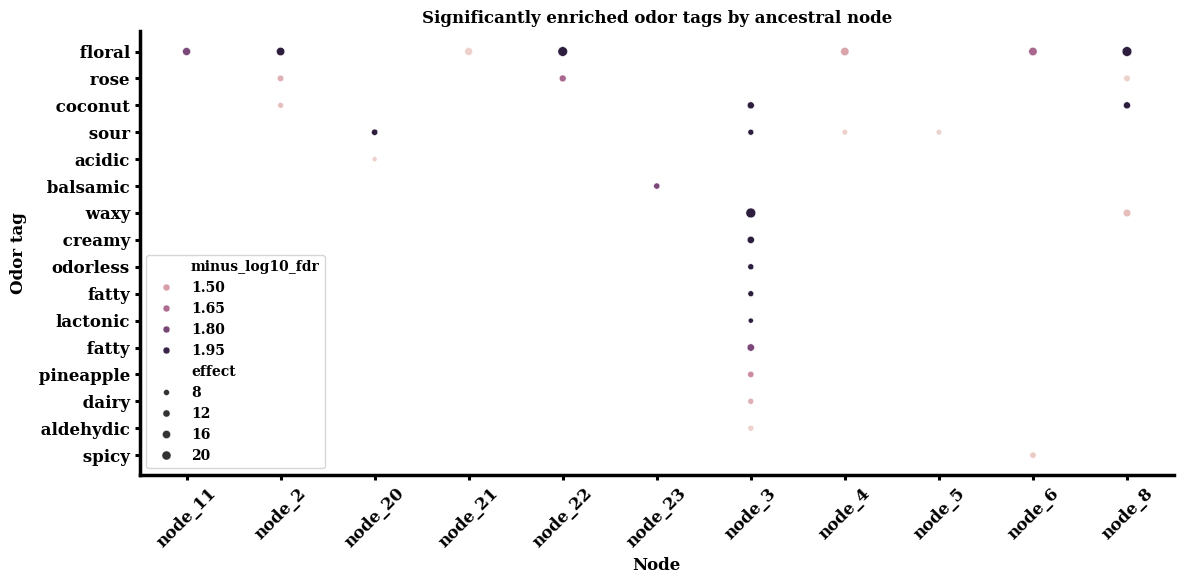

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plot_df = enriched_only.copy()
plot_df["minus_log10_fdr"] = -np.log10(plot_df["p_adj_fdr"])

plt.figure(figsize=(12, max(6, 0.35 * len(plot_df["tag"].unique()))))
sns.scatterplot(
    data=plot_df,
    x="node",
    y="tag",
    size="effect",
    hue="minus_log10_fdr"
)
plt.title("Significantly enriched odor tags by ancestral node")
plt.xlabel("Node")
plt.ylabel("Odor tag")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()